<a href="https://colab.research.google.com/github/vishalmmca25-design/ml-and-datavisualization/blob/main/pandas_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 0 — SetuP

pandas is already installed in Google Colab. We just need to **import** it.

The line `import pandas as pd` means: load the pandas library and give it the short name `pd`. Everybody writes it this way, and the whole pandas documentation assumes it.

In [ ]:
import pandas as pd

print("pandas version:", pd.__version__)

pandas version: 2.2.2


That is the only setup needed. If the version number printed, you are ready.

---

## Part 1 — What is a DataFrame?

A **DataFrame** is a table. It has:

- **columns**, each with a name (like `name`, `age`, `salary`)
- **rows**, each with a label (called the **index**)

If you have used Excel or Google Sheets, a DataFrame is the same idea: a sheet with headers.

### Making a DataFrame from a dictionary

The easiest way to create one by hand is from a Python dictionary:

- each **key** becomes a **column name**
- each **list of values** becomes the **column's data**

In [ ]:
data = {
    "name":  ["Aarav", "Priya", "Rohan"],
    "age":   [25, 31, 28],
    "city":  ["Mumbai", "Pune", "Mumbai"],
}

df_small = pd.DataFrame(data)
df_small

,name,age,city
0,Aarav,25,Mumbai
1,Priya,31,Pune
2,Rohan,28,Mumbai


Look at what got printed.

- The top row `name  age  city` is the **column names** (from the dictionary keys).
- The numbers `0  1  2` on the left are the **index** — the row labels. pandas created them automatically, starting at 0.

The index is not a column. It is the label of each row.

### Now our real table for today

We will use a small table of 12 employees for the whole lab. It is deliberately small so you can check every answer with your own eyes.

In [ ]:
data = {
    "name":       ["Aarav", "Priya", "Rohan", "Sneha", "Vikram", "Anita",
                   "Karan", "Meera", "Arjun", "Divya", "Nikhil", "Pooja"],
    "department": ["Sales", "IT", "IT", "HR", "Sales", "IT",
                   "HR", "Sales", "IT", "HR", "Sales", "IT"],
    "city":       ["Mumbai", "Pune", "Mumbai", "Delhi", "Pune", "Delhi",
                   "Mumbai", "Delhi", "Pune", "Mumbai", "Delhi", "Pune"],
    "age":        [25, 31, 28, 45, 38, 29, 41, 33, 26, 36, 48, 30],
    "salary":     [42000, 65000, 58000, 71000, 52000, 61000,
                   48000, 55000, 59000, 67000, 74000, 63000],
    "experience": [2, 6, 4, 20, 12, 5, 15, 8, 3, 11, 22, 7],
}

df = pd.DataFrame(data)
df

,name,department,city,age,salary,experience
0,Aarav,Sales,Mumbai,25,42000,2
1,Priya,IT,Pune,31,65000,6
2,Rohan,IT,Mumbai,28,58000,4
3,Sneha,HR,Delhi,45,71000,20
4,Vikram,Sales,Pune,38,52000,12
5,Anita,IT,Delhi,29,61000,5
6,Karan,HR,Mumbai,41,48000,15
7,Meera,Sales,Delhi,33,55000,8
8,Arjun,IT,Pune,26,59000,3
9,Divya,HR,Mumbai,36,67000,11


Twelve rows, six columns. Take a moment to actually read the table — you will need to recognise these values later.

### A Series is one single column

When you take one column out of a DataFrame, what you get back is called a **Series**.

A DataFrame is a table. A Series is a single column of that table.

In [ ]:
ages = df["age"]
ages

,age
0,25
1,31
2,28
3,45
4,38
5,29
6,41
7,33
8,26
9,36


Notice:

- there is only one column of numbers now
- the index `0` to `11` is still there
- at the bottom it says `Name: age, dtype: int64` — the name of the column and the **data type** (`int64` means whole numbers)

In [ ]:
print(type(df))        # the whole table
print(type(df["age"]))  # one column

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


### Four things to check about any table

These four are the first things you type when you meet a new dataset.

In [ ]:
df.shape       # (number of rows, number of columns)

(12, 6)

`df.shape` gives `(12, 6)` — 12 rows and 6 columns.

Note there are **no brackets** after `shape`. It is an attribute (a piece of information), not a method (an action).

In [ ]:
df.columns     # the column names

Index(['name', 'department', 'city', 'age', 'salary', 'experience'], dtype='object')

In [ ]:
df.index       # the row labels

RangeIndex(start=0, stop=12, step=1)

In [ ]:
df.dtypes      # the data type of each column

,0
name,object
department,object
city,object
age,int64
salary,int64
experience,int64


`int64` means whole numbers. `object` means text. pandas works out the type for each column by itself.

### EXERCISE 1  (5 minutes)

Write one line of code for each.

1. Print the number of rows only (hint: `df.shape` gives a pair, so take the first item with `[0]`).
2. Show the column named `salary`.
3. Show the column named `city`.
4. Make your own DataFrame called `my_df` from a dictionary with two columns: `subject` (`"Maths"`, `"Physics"`) and `marks` (`88`, `76`). Display it.

*Try it yourself in the cell below, then check the answer.*

In [ ]:
# 1.


# 2.


# 3.


# 4.

**Answer**

In [ ]:
# 1.
print(df.shape[0])

# 2.
print(df["salary"])

# 3.
print(df["city"])

# 4.
my_df = pd.DataFrame({"subject": ["Maths", "Physics"], "marks": [88, 76]})
print(my_df)

12
0     42000
1     65000
2     58000
3     71000
4     52000
5     61000
6     48000
7     55000
8     59000
9     67000
10    74000
11    63000
Name: salary, dtype: int64
0     Mumbai
1       Pune
2     Mumbai
3      Delhi
4       Pune
5      Delhi
6     Mumbai
7      Delhi
8       Pune
9     Mumbai
10     Delhi
11      Pune
Name: city, dtype: object
   subject  marks
0    Maths     88
1  Physics     76


---

## Part 2 — Reading and writing files

In real work you almost never type the data by hand. It comes from a file, usually a **CSV** (comma-separated values) file.

### Writing to a CSV file

Let us first save our table to a file, so that we have a file to read back.

In [ ]:
df.to_csv("employees.csv", index=False)

print("File saved.")

File saved.


`index=False` tells pandas: do not write the row labels (0, 1, 2...) into the file. Without it you get an extra useless column in the file.

You can see the file in Colab by clicking the **folder icon** on the left sidebar.

In [ ]:
# Let's look at what the file actually contains — it is just plain text
print(open("employees.csv").read())

name,department,city,age,salary,experience
Aarav,Sales,Mumbai,25,42000,2
Priya,IT,Pune,31,65000,6
Rohan,IT,Mumbai,28,58000,4
Sneha,HR,Delhi,45,71000,20
Vikram,Sales,Pune,38,52000,12
Anita,IT,Delhi,29,61000,5
Karan,HR,Mumbai,41,48000,15
Meera,Sales,Delhi,33,55000,8
Arjun,IT,Pune,26,59000,3
Divya,HR,Mumbai,36,67000,11
Nikhil,Sales,Delhi,48,74000,22
Pooja,IT,Pune,30,63000,7



That is all a CSV is: one line per row, values separated by commas, first line is the headers.

### Reading a CSV file

This is the command you will use most often in your entire pandas life:

In [ ]:
df = pd.read_csv("employees.csv")
df

,name,department,city,age,salary,experience
0,Aarav,Sales,Mumbai,25,42000,2
1,Priya,IT,Pune,31,65000,6
2,Rohan,IT,Mumbai,28,58000,4
3,Sneha,HR,Delhi,45,71000,20
4,Vikram,Sales,Pune,38,52000,12
5,Anita,IT,Delhi,29,61000,5
6,Karan,HR,Mumbai,41,48000,15
7,Meera,Sales,Delhi,33,55000,8
8,Arjun,IT,Pune,26,59000,3
9,Divya,HR,Mumbai,36,67000,11


Same table, now loaded from the file.

### Looking at your data

Real files have thousands of rows, so you never print the whole thing. You look at a piece of it.

In [ ]:
df.head()      # first 5 rows

,name,department,city,age,salary,experience
0,Aarav,Sales,Mumbai,25,42000,2
1,Priya,IT,Pune,31,65000,6
2,Rohan,IT,Mumbai,28,58000,4
3,Sneha,HR,Delhi,45,71000,20
4,Vikram,Sales,Pune,38,52000,12


In [ ]:
df.head(3)     # first 3 rows

,name,department,city,age,salary,experience
0,Aarav,Sales,Mumbai,25,42000,2
1,Priya,IT,Pune,31,65000,6
2,Rohan,IT,Mumbai,28,58000,4


In [ ]:
df.tail(2)     # last 2 rows

,name,department,city,age,salary,experience
10,Nikhil,Sales,Delhi,48,74000,22
11,Pooja,IT,Pune,30,63000,7


### `info()` — the overall summary

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        12 non-null     object
 1   department  12 non-null     object
 2   city        12 non-null     object
 3   age         12 non-null     int64 
 4   salary      12 non-null     int64 
 5   experience  12 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 708.0+ bytes


Read this output carefully. It tells you:

- how many rows there are (`12 entries, 0 to 11`)
- every column name
- `Non-Null Count` — how many values are actually present in each column
- `Dtype` — the type of each column

If a column shows fewer non-null values than the total row count, that column has **missing data**. Ours has none yet.

### `describe()` — statistics for number columns

In [ ]:
df.describe()

,age,salary,experience
count,12.000000,12.000000,12.000000
mean,34.166667,59583.333333,9.583333
std,7.493431,9346.446416,6.570711
min,25.000000,42000.000000,2.000000
25%,28.750000,54250.000000,4.750000
50%,32.000000,60000.000000,7.500000
75%,38.750000,65500.000000,12.750000
max,48.000000,74000.000000,22.000000


For every numeric column this gives:

| Row | Meaning |
|---|---|
| `count` | how many values |
| `mean` | average |
| `std` | standard deviation (how spread out) |
| `min` | smallest |
| `25%` | first quartile |
| `50%` | median (middle value) |
| `75%` | third quartile |
| `max` | largest |

Text columns like `name` and `city` are ignored because you cannot average text.

### EXERCISE 2  (6 minutes)

1. Show the first 4 rows.
2. Show the last 3 rows.
3. From `df.describe()`, what is the **average salary**? Write it as a comment.
4. What is the **maximum age** in the table?
5. Save only the first 5 rows to a new file called `top5.csv`, then read it back and display it.

*Try it yourself in the cell below, then check the answer.*

In [ ]:
# 1.


# 2.


# 3.  average salary =


# 4.


# 5.

**Answer**

In [ ]:
# 1.
print(df.head(4))

# 2.
print(df.tail(3))

# 3.  average salary = 59583.33
print("average salary:", df["salary"].mean())

# 4.
print("maximum age:", df["age"].max())

# 5.
df.head(5).to_csv("top5.csv", index=False)
top5 = pd.read_csv("top5.csv")
print(top5)

    name department    city  age  salary  experience
0  Aarav      Sales  Mumbai   25   42000           2
1  Priya         IT    Pune   31   65000           6
2  Rohan         IT  Mumbai   28   58000           4
3  Sneha         HR   Delhi   45   71000          20
      name department    city  age  salary  experience
9    Divya         HR  Mumbai   36   67000          11
10  Nikhil      Sales   Delhi   48   74000          22
11   Pooja         IT    Pune   30   63000           7
average salary: 59583.333333333336
maximum age: 48
     name department    city  age  salary  experience
0   Aarav      Sales  Mumbai   25   42000           2
1   Priya         IT    Pune   31   65000           6
2   Rohan         IT  Mumbai   28   58000           4
3   Sneha         HR   Delhi   45   71000          20
4  Vikram      Sales    Pune   38   52000          12


---

## Part 3 — Selecting columns and rows

This part is about picking out the piece of the table you want.

### Selecting one column

Put the column name in square brackets. The result is a **Series**.

In [ ]:
df["name"]

,name
0,Aarav
1,Priya
2,Rohan
3,Sneha
4,Vikram
5,Anita
6,Karan
7,Meera
8,Arjun
9,Divya


### Selecting several columns

Put a **list** of names inside the square brackets. So there are **two** sets of brackets: the outer one for selecting, the inner one making the list.

The result is a **DataFrame**, because more than one column is a table.

In [ ]:
df[["name", "salary"]]

,name,salary
0,Aarav,42000
1,Priya,65000
2,Rohan,58000
3,Sneha,71000
4,Vikram,52000
5,Anita,61000
6,Karan,48000
7,Meera,55000
8,Arjun,59000
9,Divya,67000


This double-bracket thing confuses everybody at first. Remember:

- `df["name"]` → one column → Series
- `df[["name"]]` → a list with one name in it → still a small table → DataFrame

In [ ]:
print(type(df["name"]))     # Series
print(type(df[["name"]]))   # DataFrame

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


### Selecting rows

There are two tools, and the difference matters:

| Tool | Selects by | Meaning |
|---|---|---|
| `df.loc[...]` | **label** | the row's index label |
| `df.iloc[...]` | **position** | the row's position, counting from 0 |

In our table the index labels happen to be 0, 1, 2..., which are also the positions, so both look the same for now. They stop being the same as soon as you sort or filter the table.

In [ ]:
df.loc[0]        # the row whose label is 0

,0
name,Aarav
department,Sales
city,Mumbai
age,25
salary,42000
experience,2


In [ ]:
df.iloc[0]       # the row in position 0 (the first row)

,0
name,Aarav
department,Sales
city,Mumbai
age,25
salary,42000
experience,2


### Selecting several rows

In [ ]:
df.loc[0:3]      # labels 0 to 3 — gives 4 rows, the last one IS included

,name,department,city,age,salary,experience
0,Aarav,Sales,Mumbai,25,42000,2
1,Priya,IT,Pune,31,65000,6
2,Rohan,IT,Mumbai,28,58000,4
3,Sneha,HR,Delhi,45,71000,20


In [ ]:
df.iloc[0:3]     # positions 0, 1, 2 — gives 3 rows, the last one is NOT included

,name,department,city,age,salary,experience
0,Aarav,Sales,Mumbai,25,42000,2
1,Priya,IT,Pune,31,65000,6
2,Rohan,IT,Mumbai,28,58000,4


**Important:** `loc` includes the last item, `iloc` does not. This is the single most common beginner mistake. Count the rows in the two outputs above and confirm it for yourself.

### Selecting rows AND columns together

The pattern is `df.loc[rows, columns]`.

In [ ]:
df.loc[0:4, ["name", "department", "salary"]]

,name,department,salary
0,Aarav,Sales,42000
1,Priya,IT,65000
2,Rohan,IT,58000
3,Sneha,HR,71000
4,Vikram,Sales,52000


In [ ]:
df.iloc[0:4, 0:3]      # first 4 rows, first 3 columns, by position

,name,department,city
0,Aarav,Sales,Mumbai
1,Priya,IT,Pune
2,Rohan,IT,Mumbai
3,Sneha,HR,Delhi


### One single value

In [ ]:
df.loc[2, "name"]      # the name in row 2

'Rohan'

### EXERCISE 3  (8 minutes)

1. Show only the `department` column.
2. Show the `name` and `age` columns together.
3. Show rows with labels 5 to 8 (all columns).
4. Show the first 3 rows using `.iloc`.
5. Show the `name` and `city` of rows 0 to 4 in one command.
6. Get the salary of the row with label 10.

*Try it yourself in the cell below, then check the answer.*

In [ ]:
# 1.


# 2.


# 3.


# 4.


# 5.


# 6.

**Answer**

In [ ]:
# 1.
print(df["department"])

# 2.
print(df[["name", "age"]])

# 3.
print(df.loc[5:8])

# 4.
print(df.iloc[0:3])

# 5.
print(df.loc[0:4, ["name", "city"]])

# 6.
print(df.loc[10, "salary"])

0     Sales
1        IT
2        IT
3        HR
4     Sales
5        IT
6        HR
7     Sales
8        IT
9        HR
10    Sales
11       IT
Name: department, dtype: object
      name  age
0    Aarav   25
1    Priya   31
2    Rohan   28
3    Sneha   45
4   Vikram   38
5    Anita   29
6    Karan   41
7    Meera   33
8    Arjun   26
9    Divya   36
10  Nikhil   48
11   Pooja   30
    name department    city  age  salary  experience
5  Anita         IT   Delhi   29   61000           5
6  Karan         HR  Mumbai   41   48000          15
7  Meera      Sales   Delhi   33   55000           8
8  Arjun         IT    Pune   26   59000           3
    name department    city  age  salary  experience
0  Aarav      Sales  Mumbai   25   42000           2
1  Priya         IT    Pune   31   65000           6
2  Rohan         IT  Mumbai   28   58000           4
     name    city
0   Aarav  Mumbai
1   Priya    Pune
2   Rohan  Mumbai
3   Sneha   Delhi
4  Vikram    Pune
74000


---

## Part 4 — Filtering rows with a condition

This is the most useful thing pandas does: **keep only the rows that satisfy a condition**.

It happens in two steps. Understand step 1 properly and step 2 is easy.

### Step 1 — a condition gives True/False for every row

In [ ]:
df["age"] > 30

,age
0,False
1,True
2,False
3,True
4,True
5,False
6,True
7,True
8,False
9,True


Look at this output. It is **not** the answer yet. It is a Series of `True` and `False` — one for every row in the table.

Row 0 is `False` because Aarav is 25. Row 1 is `True` because Priya is 31. Check a few against the original table.

This True/False Series is called a **mask** or a **condition**.

### Step 2 — put the condition inside `df[...]`

pandas keeps only the rows where the condition is `True`.

In [ ]:
df[df["age"] > 30]

,name,department,city,age,salary,experience
1,Priya,IT,Pune,31,65000,6
3,Sneha,HR,Delhi,45,71000,20
4,Vikram,Sales,Pune,38,52000,12
6,Karan,HR,Mumbai,41,48000,15
7,Meera,Sales,Delhi,33,55000,8
9,Divya,HR,Mumbai,36,67000,11
10,Nikhil,Sales,Delhi,48,74000,22


That is the whole idea. The inner part `df["age"] > 30` produces True/False, and the outer `df[...]` keeps the True rows.

Read it aloud as: *"df where df's age is greater than 30"*.

### More examples

In [ ]:
df[df["salary"] > 60000]

,name,department,city,age,salary,experience
1,Priya,IT,Pune,31,65000,6
3,Sneha,HR,Delhi,45,71000,20
5,Anita,IT,Delhi,29,61000,5
9,Divya,HR,Mumbai,36,67000,11
10,Nikhil,Sales,Delhi,48,74000,22
11,Pooja,IT,Pune,30,63000,7


In [ ]:
df[df["department"] == "IT"]

,name,department,city,age,salary,experience
1,Priya,IT,Pune,31,65000,6
2,Rohan,IT,Mumbai,28,58000,4
5,Anita,IT,Delhi,29,61000,5
8,Arjun,IT,Pune,26,59000,3
11,Pooja,IT,Pune,30,63000,7


Note `==` with two equals signs. One `=` assigns a value; two `==` compares.

In [ ]:
df[df["city"] != "Mumbai"]        # != means "not equal to"

,name,department,city,age,salary,experience
1,Priya,IT,Pune,31,65000,6
3,Sneha,HR,Delhi,45,71000,20
4,Vikram,Sales,Pune,38,52000,12
5,Anita,IT,Delhi,29,61000,5
7,Meera,Sales,Delhi,33,55000,8
8,Arjun,IT,Pune,26,59000,3
10,Nikhil,Sales,Delhi,48,74000,22
11,Pooja,IT,Pune,30,63000,7


### Two conditions at the same time

Use `&` for AND, `|` for OR.

**Each condition must be inside its own round brackets.** If you forget the brackets you get an error.

In [ ]:
df[(df["department"] == "IT") & (df["salary"] > 60000)]

,name,department,city,age,salary,experience
1,Priya,IT,Pune,31,65000,6
5,Anita,IT,Delhi,29,61000,5
11,Pooja,IT,Pune,30,63000,7


That is: IT department **AND** salary above 60000.

In [ ]:
df[(df["city"] == "Mumbai") | (df["city"] == "Delhi")]

,name,department,city,age,salary,experience
0,Aarav,Sales,Mumbai,25,42000,2
2,Rohan,IT,Mumbai,28,58000,4
3,Sneha,HR,Delhi,45,71000,20
5,Anita,IT,Delhi,29,61000,5
6,Karan,HR,Mumbai,41,48000,15
7,Meera,Sales,Delhi,33,55000,8
9,Divya,HR,Mumbai,36,67000,11
10,Nikhil,Sales,Delhi,48,74000,22


That is: Mumbai **OR** Delhi.

Do not write `and` / `or` here — pandas needs the symbols `&` and `|`.

### `isin` — a shortcut for "is one of these"

Writing many `|` conditions gets long. `isin` takes a list.

In [ ]:
df[df["city"].isin(["Mumbai", "Delhi"])]

,name,department,city,age,salary,experience
0,Aarav,Sales,Mumbai,25,42000,2
2,Rohan,IT,Mumbai,28,58000,4
3,Sneha,HR,Delhi,45,71000,20
5,Anita,IT,Delhi,29,61000,5
6,Karan,HR,Mumbai,41,48000,15
7,Meera,Sales,Delhi,33,55000,8
9,Divya,HR,Mumbai,36,67000,11
10,Nikhil,Sales,Delhi,48,74000,22


Same result as the `|` version above, but shorter and easier to read.

### Sorting

Often you filter and then sort.

In [ ]:
df.sort_values("salary")                        # smallest first

,name,department,city,age,salary,experience
0,Aarav,Sales,Mumbai,25,42000,2
6,Karan,HR,Mumbai,41,48000,15
4,Vikram,Sales,Pune,38,52000,12
7,Meera,Sales,Delhi,33,55000,8
2,Rohan,IT,Mumbai,28,58000,4
8,Arjun,IT,Pune,26,59000,3
5,Anita,IT,Delhi,29,61000,5
11,Pooja,IT,Pune,30,63000,7
1,Priya,IT,Pune,31,65000,6
9,Divya,HR,Mumbai,36,67000,11


In [ ]:
df.sort_values("salary", ascending=False)       # largest first

,name,department,city,age,salary,experience
10,Nikhil,Sales,Delhi,48,74000,22
3,Sneha,HR,Delhi,45,71000,20
9,Divya,HR,Mumbai,36,67000,11
1,Priya,IT,Pune,31,65000,6
11,Pooja,IT,Pune,30,63000,7
5,Anita,IT,Delhi,29,61000,5
8,Arjun,IT,Pune,26,59000,3
2,Rohan,IT,Mumbai,28,58000,4
7,Meera,Sales,Delhi,33,55000,8
4,Vikram,Sales,Pune,38,52000,12


In [ ]:
df.sort_values("salary", ascending=False).head(3)   # top 3 earners

,name,department,city,age,salary,experience
10,Nikhil,Sales,Delhi,48,74000,22
3,Sneha,HR,Delhi,45,71000,20
9,Divya,HR,Mumbai,36,67000,11


### EXERCISE 4  (10 minutes)

1. Show all employees older than 35.
2. Show all employees in the `Sales` department.
3. Show all employees with `experience` of 10 years or more.
4. Show employees who are in `HR` **and** earn more than 50000.
5. Show employees from Pune **or** Delhi, using `isin`.
6. Show the 3 youngest employees (sort by age, then `head(3)`).

*Try it yourself in the cell below, then check the answer.*

In [ ]:
# 1.


# 2.


# 3.


# 4.


# 5.


# 6.

**Answer**

In [ ]:
# 1.
print(df[df["age"] > 35])

# 2.
print(df[df["department"] == "Sales"])

# 3.
print(df[df["experience"] >= 10])

# 4.
print(df[(df["department"] == "HR") & (df["salary"] > 50000)])

# 5.
print(df[df["city"].isin(["Pune", "Delhi"])])

# 6.
print(df.sort_values("age").head(3))

      name department    city  age  salary  experience
3    Sneha         HR   Delhi   45   71000          20
4   Vikram      Sales    Pune   38   52000          12
6    Karan         HR  Mumbai   41   48000          15
9    Divya         HR  Mumbai   36   67000          11
10  Nikhil      Sales   Delhi   48   74000          22
      name department    city  age  salary  experience
0    Aarav      Sales  Mumbai   25   42000           2
4   Vikram      Sales    Pune   38   52000          12
7    Meera      Sales   Delhi   33   55000           8
10  Nikhil      Sales   Delhi   48   74000          22
      name department    city  age  salary  experience
3    Sneha         HR   Delhi   45   71000          20
4   Vikram      Sales    Pune   38   52000          12
6    Karan         HR  Mumbai   41   48000          15
9    Divya         HR  Mumbai   36   67000          11
10  Nikhil      Sales   Delhi   48   74000          22
    name department    city  age  salary  experience
3  Sneha    

---

## Part 5 — Making new columns

To create a new column, write the new name in square brackets on the left of `=`.

In [ ]:
df["bonus"] = df["salary"] * 0.10
df

,name,department,city,age,salary,experience,bonus
0,Aarav,Sales,Mumbai,25,42000,2,4200.0
1,Priya,IT,Pune,31,65000,6,6500.0
2,Rohan,IT,Mumbai,28,58000,4,5800.0
3,Sneha,HR,Delhi,45,71000,20,7100.0
4,Vikram,Sales,Pune,38,52000,12,5200.0
5,Anita,IT,Delhi,29,61000,5,6100.0
6,Karan,HR,Mumbai,41,48000,15,4800.0
7,Meera,Sales,Delhi,33,55000,8,5500.0
8,Arjun,IT,Pune,26,59000,3,5900.0
9,Divya,HR,Mumbai,36,67000,11,6700.0


Notice what happened: pandas multiplied **every** salary by 0.10 in one go. You did not write a loop.

This is the pandas way of working. Whenever you want to do something to a whole column, do the arithmetic on the column directly.

In [ ]:
df["total_pay"] = df["salary"] + df["bonus"]
df[["name", "salary", "bonus", "total_pay"]]

,name,salary,bonus,total_pay
0,Aarav,42000,4200.0,46200.0
1,Priya,65000,6500.0,71500.0
2,Rohan,58000,5800.0,63800.0
3,Sneha,71000,7100.0,78100.0
4,Vikram,52000,5200.0,57200.0
5,Anita,61000,6100.0,67100.0
6,Karan,48000,4800.0,52800.0
7,Meera,55000,5500.0,60500.0
8,Arjun,59000,5900.0,64900.0
9,Divya,67000,6700.0,73700.0


### A new column from a condition

In [ ]:
df["senior"] = df["experience"] >= 10
df[["name", "experience", "senior"]]

,name,experience,senior
0,Aarav,2,False
1,Priya,6,False
2,Rohan,4,False
3,Sneha,20,True
4,Vikram,12,True
5,Anita,5,False
6,Karan,15,True
7,Meera,8,False
8,Arjun,3,False
9,Divya,11,True


### Renaming a column

In [ ]:
df = df.rename(columns={"total_pay": "annual_pay"})
df.columns

Index(['name', 'department', 'city', 'age', 'salary', 'experience', 'bonus',
       'annual_pay', 'senior'],
      dtype='object')

### Removing a column

`axis=1` means "a column" (`axis=0` would mean a row).

In [ ]:
df = df.drop("senior", axis=1)
df.columns

Index(['name', 'department', 'city', 'age', 'salary', 'experience', 'bonus',
       'annual_pay'],
      dtype='object')

### EXERCISE 5  (8 minutes)

1. Create a column `monthly_salary` = `salary` divided by 12.
2. Create a column `tax` = 5% of `salary`.
3. Create a column `experienced` that is `True` when `experience` is more than 5.
4. Rename the column `monthly_salary` to `monthly_pay`.
5. Delete the `tax` column.

*Try it yourself in the cell below, then check the answer.*

In [ ]:
# 1.


# 2.


# 3.


# 4.


# 5.

**Answer**

In [ ]:
# 1.
df["monthly_salary"] = df["salary"] / 12

# 2.
df["tax"] = df["salary"] * 0.05

# 3.
df["experienced"] = df["experience"] > 5

# 4.
df = df.rename(columns={"monthly_salary": "monthly_pay"})

# 5.
df = df.drop("tax", axis=1)

print(df.columns.tolist())
display(df[["name", "salary", "monthly_pay", "experienced", "city"]].head())

['name', 'department', 'city', 'age', 'salary', 'experience', 'bonus', 'annual_pay', 'monthly_pay', 'experienced']


,name,salary,monthly_pay,experienced,city
0,Aarav,42000,3500.000000,False,Mumbai
1,Priya,65000,5416.666667,True,Pune
2,Rohan,58000,4833.333333,False,Mumbai
3,Sneha,71000,5916.666667,True,Delhi
4,Vikram,52000,4333.333333,True,Pune


---

## Part 6 — Summary statistics and grouping

### Statistics on one column

In [ ]:
print("mean salary  :", df["salary"].mean())
print("total salary :", df["salary"].sum())
print("max salary   :", df["salary"].max())
print("min salary   :", df["salary"].min())
print("count        :", df["salary"].count())

mean salary  : 59583.333333333336
total salary : 715000
max salary   : 74000
min salary   : 42000
count        : 12


The same methods work on any numeric column.

In [ ]:
df["age"].mean()

np.float64(34.166666666666664)

### Counting text values

`value_counts()` counts how many times each value appears. Use it constantly.

In [ ]:
df["department"].value_counts()

,count
department,
IT,5
Sales,4
HR,3


In [ ]:
df["city"].value_counts()

,count
city,
Mumbai,4
Pune,4
Delhi,4


### `groupby` — the most important idea in this lab

So far all our statistics were for the whole table. Usually you want them **per group**: average salary per department, total sales per city, and so on.

`groupby` does three things:

1. **splits** the rows into groups
2. **calculates** something for each group
3. **combines** the answers into one small table

In [ ]:
df.groupby("department")["salary"].mean()

,salary
department,
HR,62000.0
IT,61200.0
Sales,55750.0


Read this command left to right:

- `df.groupby("department")` — split the rows into groups by department (HR, IT, Sales)
- `["salary"]` — look at the salary column
- `.mean()` — take the average of each group

The result has one row per department. The department names have become the index.

In [ ]:
df.groupby("department")["salary"].sum()

,salary
department,
HR,186000
IT,306000
Sales,223000


In [ ]:
df.groupby("city")["salary"].mean()

,salary
city,
Delhi,65250.0
Mumbai,53750.0
Pune,59750.0


In [ ]:
df.groupby("department")["name"].count()      # how many people in each department

,name
department,
HR,3
IT,5
Sales,4


### Grouping and sorting together

In [ ]:
df.groupby("department")["salary"].mean().sort_values(ascending=False)

,salary
department,
HR,62000.0
IT,61200.0
Sales,55750.0


### Several statistics at once with `agg`

In [ ]:
df.groupby("department")["salary"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
department,,,,
HR,3,62000.0,48000,71000
IT,5,61200.0,58000,65000
Sales,4,55750.0,42000,74000


### Grouping by two columns

In [ ]:
df.groupby(["department", "city"])["salary"].mean()

department  city  
HR          Delhi     71000.000000
            Mumbai    57500.000000
IT          Delhi     61000.000000
            Mumbai    58000.000000
            Pune      62333.333333
Sales       Delhi     64500.000000
            Mumbai    42000.000000
            Pune      52000.000000
Name: salary, dtype: float64

### EXERCISE 6  (10 minutes)

1. What is the average `age` of all employees?
2. How many employees are there in each `city`? (use `value_counts`)
3. What is the average `salary` for each `city`?
4. What is the **total** salary paid by each `department`?
5. What is the average `experience` per `department`, sorted from highest to lowest?
6. Using `agg`, show the count, mean and max of `age` for each `department`.

*Try it yourself in the cell below, then check the answer.*

In [ ]:
# 1.


# 2.


# 3.


# 4.


# 5.


# 6.

**Answer**

In [ ]:
# 1.
print("average age:", df["age"].mean())

# 2.
print(df["city"].value_counts())

# 3.
print(df.groupby("city")["salary"].mean())

# 4.
print(df.groupby("department")["salary"].sum())

# 5.
print(df.groupby("department")["experience"].mean().sort_values(ascending=False))

# 6.
print(df.groupby("department")["age"].agg(["count", "mean", "max"]))

average age: 34.166666666666664
city
Mumbai    4
Pune      4
Delhi     4
Name: count, dtype: int64
city
Delhi     65250.0
Mumbai    53750.0
Pune      59750.0
Name: salary, dtype: float64
department
HR       186000
IT       306000
Sales    223000
Name: salary, dtype: int64
department
HR       15.333333
Sales    11.000000
IT        5.000000
Name: experience, dtype: float64
            count       mean  max
department                       
HR              3  40.666667   45
IT              5  28.800000   31
Sales           4  36.000000   48


---

## Part 7 — Missing values

Real data files almost always have blank cells. pandas shows a blank as `NaN`, which means "Not a Number" — pandas' way of saying *no value here*.

Let us make a copy of our table with two values removed, so you can see how to deal with it.

In [ ]:
df2 = df.copy()
df2.loc[3, "age"] = None
df2.loc[7, "salary"] = None

df2[["name", "age", "salary"]]

,name,age,salary
0,Aarav,25.0,42000.0
1,Priya,31.0,65000.0
2,Rohan,28.0,58000.0
3,Sneha,NaN,71000.0
4,Vikram,38.0,52000.0
5,Anita,29.0,61000.0
6,Karan,41.0,48000.0
7,Meera,33.0,NaN
8,Arjun,26.0,59000.0
9,Divya,36.0,67000.0


Rows 3 and 7 now show `NaN`.

### Finding missing values

In [ ]:
df2.isna()          # True wherever a value is missing

,name,department,city,age,salary,experience,bonus,annual_pay,monthly_pay,experienced
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,True,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False


In [ ]:
df2.isna().sum()    # count of missing values in each column

,0
name,0
department,0
city,0
age,1
salary,1
experience,0
bonus,0
annual_pay,0
monthly_pay,0
experienced,0


`isna()` gives True/False for every cell, and `.sum()` adds up the Trues per column. This one line is how you check any dataset for missing data.

In [ ]:
df2.info()          # the Non-Null Count column shows it too

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         12 non-null     object 
 1   department   12 non-null     object 
 2   city         12 non-null     object 
 3   age          11 non-null     float64
 4   salary       11 non-null     float64
 5   experience   12 non-null     int64  
 6   bonus        12 non-null     float64
 7   annual_pay   12 non-null     float64
 8   monthly_pay  12 non-null     float64
 9   experienced  12 non-null     bool   
dtypes: bool(1), float64(5), int64(1), object(3)
memory usage: 1008.0+ bytes


### Dealing with missing values

You have two basic choices.

**Option 1 — fill them in** with some value:

In [ ]:
df2["age"].fillna(0)                     # fill with 0

,age
0,25.0
1,31.0
2,28.0
3,0.0
4,38.0
5,29.0
6,41.0
7,33.0
8,26.0
9,36.0


In [ ]:
df2["age"].fillna(df2["age"].mean())     # fill with the average age — usually more sensible

,age
0,25.000000
1,31.000000
2,28.000000
3,33.181818
4,38.000000
5,29.000000
6,41.000000
7,33.000000
8,26.000000
9,36.000000


**Option 2 — remove the rows** that have missing values:

In [ ]:
print("rows before:", len(df2))
print("rows after dropna:", len(df2.dropna()))

rows before: 12
rows after dropna: 10


In [ ]:
df2.dropna()

,name,department,city,age,salary,experience,bonus,annual_pay,monthly_pay,experienced
0,Aarav,Sales,Mumbai,25.0,42000.0,2,4200.0,46200.0,3500.000000,False
1,Priya,IT,Pune,31.0,65000.0,6,6500.0,71500.0,5416.666667,True
2,Rohan,IT,Mumbai,28.0,58000.0,4,5800.0,63800.0,4833.333333,False
4,Vikram,Sales,Pune,38.0,52000.0,12,5200.0,57200.0,4333.333333,True
5,Anita,IT,Delhi,29.0,61000.0,5,6100.0,67100.0,5083.333333,False
6,Karan,HR,Mumbai,41.0,48000.0,15,4800.0,52800.0,4000.000000,True
8,Arjun,IT,Pune,26.0,59000.0,3,5900.0,64900.0,4916.666667,False
9,Divya,HR,Mumbai,36.0,67000.0,11,6700.0,73700.0,5583.333333,True
10,Nikhil,Sales,Delhi,48.0,74000.0,22,7400.0,81400.0,6166.666667,True
11,Pooja,IT,Pune,30.0,63000.0,7,6300.0,69300.0,5250.000000,True


Which to choose depends on your data. Filling keeps all your rows but invents values. Dropping is honest but loses rows. There is no universally right answer — you must decide and be able to justify it.

Note that these commands **return a new table**. The original `df2` is unchanged unless you assign the result back:

In [ ]:
df2["age"] = df2["age"].fillna(df2["age"].mean())
print("missing values now:", df2["age"].isna().sum())

missing values now: 0


### EXERCISE 7  (6 minutes)

1. Count the missing values in `df2` again. Which column still has one?
2. Fill the missing `salary` with the average salary and assign it back.
3. Confirm that `df2` now has no missing values at all (`df2.isna().sum().sum()` should give 0).

*Try it yourself in the cell below, then check the answer.*

In [ ]:
# 1.


# 2.


# 3.

**Answer**

In [ ]:
# 1.
print(df2.isna().sum())

# 2.
df2["salary"] = df2["salary"].fillna(df2["salary"].mean())

# 3.
print("total missing:", df2.isna().sum().sum())

name           0
department     0
city           0
age            0
salary         1
experience     0
bonus          0
annual_pay     0
monthly_pay    0
experienced    0
dtype: int64
total missing: 0


---

## Part 8 — a simple chart

pandas can draw basic charts directly, without learning a separate plotting library.

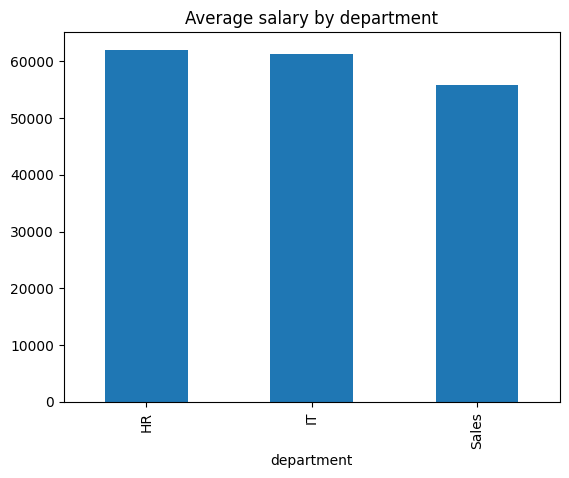

In [ ]:
df.groupby("department")["salary"].mean().plot(kind="bar", title="Average salary by department");

`kind` can be `"bar"`, `"barh"`, `"line"`, `"hist"`, `"box"`, `"scatter"`, `"pie"`.

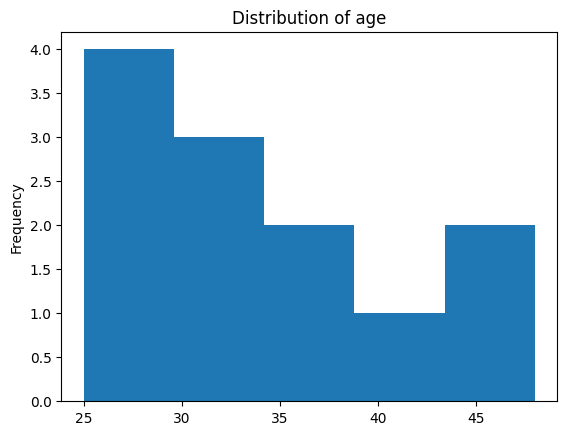

In [ ]:
df["age"].plot(kind="hist", bins=5, title="Distribution of age");

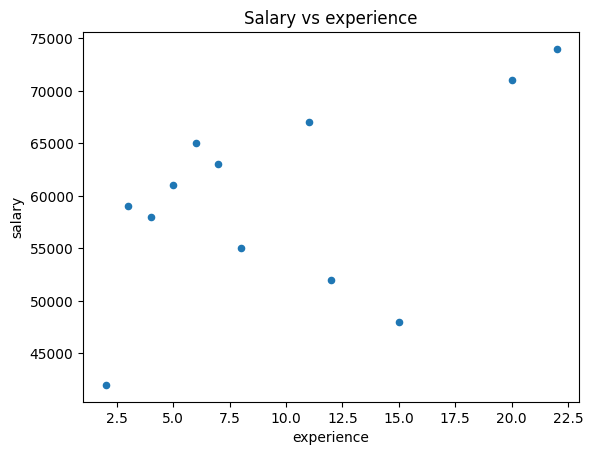

In [ ]:
df.plot(kind="scatter", x="experience", y="salary", title="Salary vs experience");

The scatter plot shows a clear pattern: more experience generally means higher salary. Making a picture is often the fastest way to notice something in your data.

---

## Summary — everything you learned today

| What you want | Command |
|---|---|
| Import pandas | `import pandas as pd` |
| Make a table | `pd.DataFrame(dictionary)` |
| Read a CSV file | `pd.read_csv("file.csv")` |
| Save a CSV file | `df.to_csv("file.csv", index=False)` |
| First 5 rows | `df.head()` |
| Last 5 rows | `df.tail()` |
| Size of table | `df.shape` |
| Column names | `df.columns` |
| Overall summary | `df.info()` |
| Statistics | `df.describe()` |
| One column | `df["salary"]` |
| Several columns | `df[["name", "salary"]]` |
| Rows by label | `df.loc[0:3]` |
| Rows by position | `df.iloc[0:3]` |
| Filter rows | `df[df["age"] > 30]` |
| Two conditions | `df[(cond1) & (cond2)]` |
| Is one of a list | `df[df["city"].isin([...])]` |
| Sort | `df.sort_values("salary", ascending=False)` |
| New column | `df["bonus"] = df["salary"] * 0.1` |
| Rename column | `df.rename(columns={"old": "new"})` |
| Delete column | `df.drop("col", axis=1)` |
| Average | `df["salary"].mean()` |
| Count each value | `df["city"].value_counts()` |
| Group and calculate | `df.groupby("dept")["salary"].mean()` |
| Find missing | `df.isna().sum()` |
| Fill missing | `df["age"].fillna(0)` |
| Drop missing rows | `df.dropna()` |
| Chart | `df.plot(kind="bar")` |

### Three rules to remember

1. `df["column"]` gives **one column** (a Series). `df[["a", "b"]]` with double brackets gives **a table**.
2. To filter, put a True/False condition inside `df[...]`. Use `&` and `|`, and put each condition in its own round brackets.
3. `.loc` uses **labels** and includes the last one. `.iloc` uses **positions** and does not.

### Practice at home

Using the same `df`:

1. Which employee has the highest salary? Print their name.
2. How many employees earn more than the average salary?
3. What is the average salary of employees with more than 10 years of experience?
4. Which city has the highest average age?
5. Add a column `salary_per_year_exp` = salary divided by experience, and find who has the highest value.

### Where to look things up

The official pandas documentation is the best reference, and it has a beginner section written exactly for this level:

- Getting started tutorials: https://pandas.pydata.org/docs/getting_started/intro_tutorials/index.html
- 10 minutes to pandas: https://pandas.pydata.org/docs/user_guide/10min.html
- Full list of DataFrame methods: https://pandas.pydata.org/docs/reference/frame.html